In [1]:
using Revise
using NMRlab

In [2]:
GISSMO.search("Gluconic acid")

2-element Vector{Any}:
 Dict{String, Any}("name" => "Gluconic acid", "id" => "bmse000084")
 Dict{String, Any}("name" => "Glutaconic-acid", "id" => "bmse000435")

In [3]:
n,H=GISSMO.Hamiltonian("bmse000084") ;
S=GISSMO.SpinMatrix("bmse000084")

6×6 Matrix{Float64}:
   3.65121  -11.5861   6.36358  0.0      0.0      0.0
 -11.5861     3.81185  3.3929   0.0      0.0      0.0
   6.36358    3.3929   3.75604  6.80365  0.0      0.0
   0.0        0.0      6.80365  3.75037  3.67274  0.0
   0.0        0.0      0.0      3.67274  4.02021  3.24248
   0.0        0.0      0.0      0.0      3.24248  4.11635

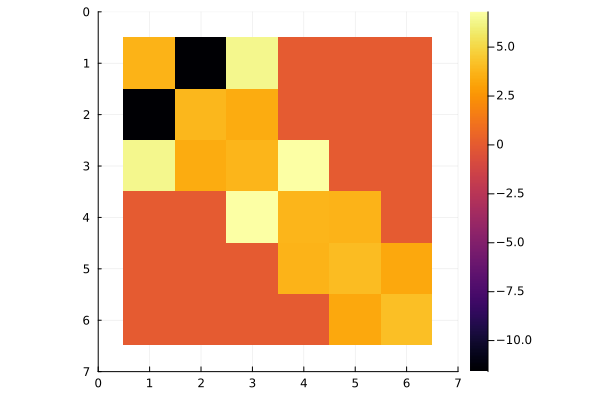

In [4]:
using Plots
Plots.heatmap(S,aspect_ratio=1,xlims=[0,7],ylims=[0,7],yaxis=:flip)

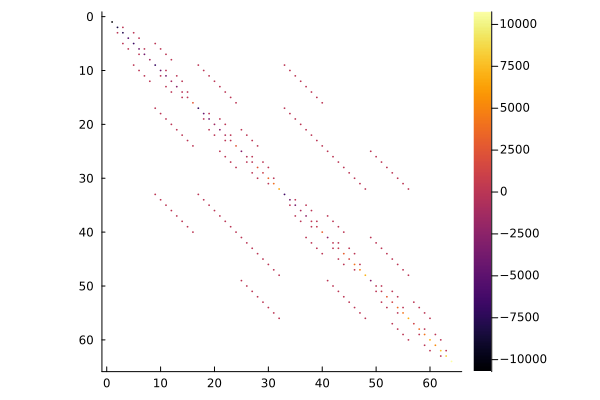

In [5]:
Plots.spy(H)

In [6]:
using LinearAlgebra
using SparseArrays

δt = π/2 / opnorm(H,Inf)
P=SpinSim.expm(-im*δt*(H))
rho0=sum(SpinSim.SpinOp(n,SpinSim.Sx,k) for k=1:n)
Fp=sum(SpinSim.SpinOp(n,SpinSim.Sp,k) for k=1:n)
fid = ComplexF64[]
sizehint!(fid,2<<14)
ρ = rho0
for k=1:2<<14
    push!(fid, tr(ρ*Fp)*exp(-2*π*k*δt))
    ρ = P*ρ*P'
    droptol!(ρ,10*eps(Float64))
end

In [7]:
using FFTW

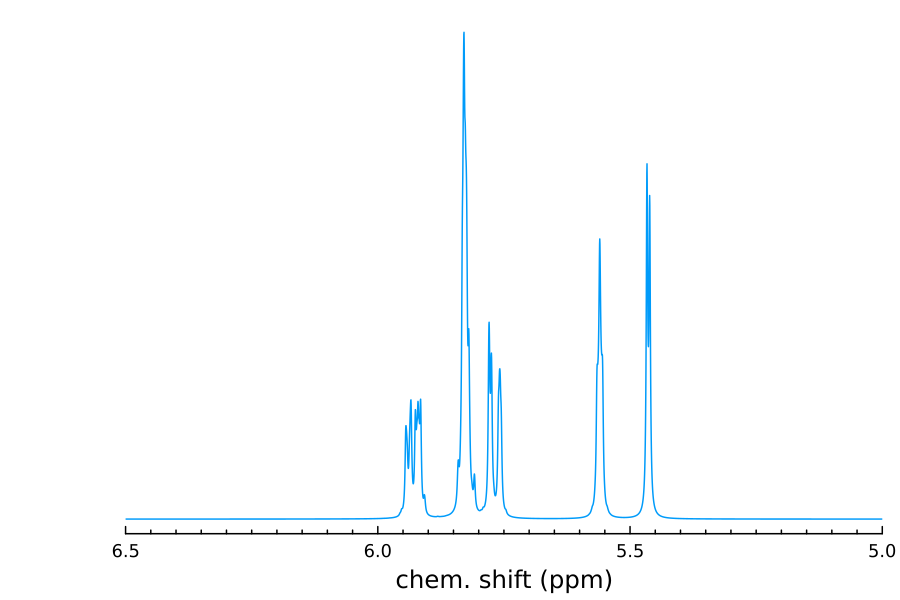

In [8]:
using Plots
Plots.plot(range(-0.5/δt,stop=0.5/δt,length=length(fid))/600.0.+4.78, 
            real.(fftshift(fft(fid))),
            xaxis=:flip,
            minorticks=10,
            xlabel="chem. shift (ppm)",
            xlims=[5,6.5],
            yaxis=false,
            grid=false,
            legend=false,
            fmt=:png,dpi=150,
)

## can we do a simulation in the Liouvillian space?

In [9]:
function vec(A::AbstractSparseMatrix)
    n,m=size(A)
    return sparsevec(reshape(A,n*m,1))
end

rho0 = sum(SpinSim.SpinOp(n,SpinSim.Sx,k) for k=1:n) |> vec
l,m=size(H)
HT=spzeros(l,l)
transpose!(HT,H)
Hsup = SpinSim.Kron(sparse(I,l,l),H) - SpinSim.Kron(HT,sparse(I,l,l))
Rsup = sparse(I,l*l,l*l)*0.5*π
Psup = SpinSim.expm(-im*δt*(Hsup-im*Rsup));

In [10]:
fidl = ComplexF64[]
sizehint!(fidl,2<<14)
Fpm=vec(Fp)
ρ = rho0
for k=1:2<<14
    push!(fidl, sum(conj.(ρ).*Fpm))
    ρ = Psup*ρ
    droptol!(ρ,10*eps(Float64))
end

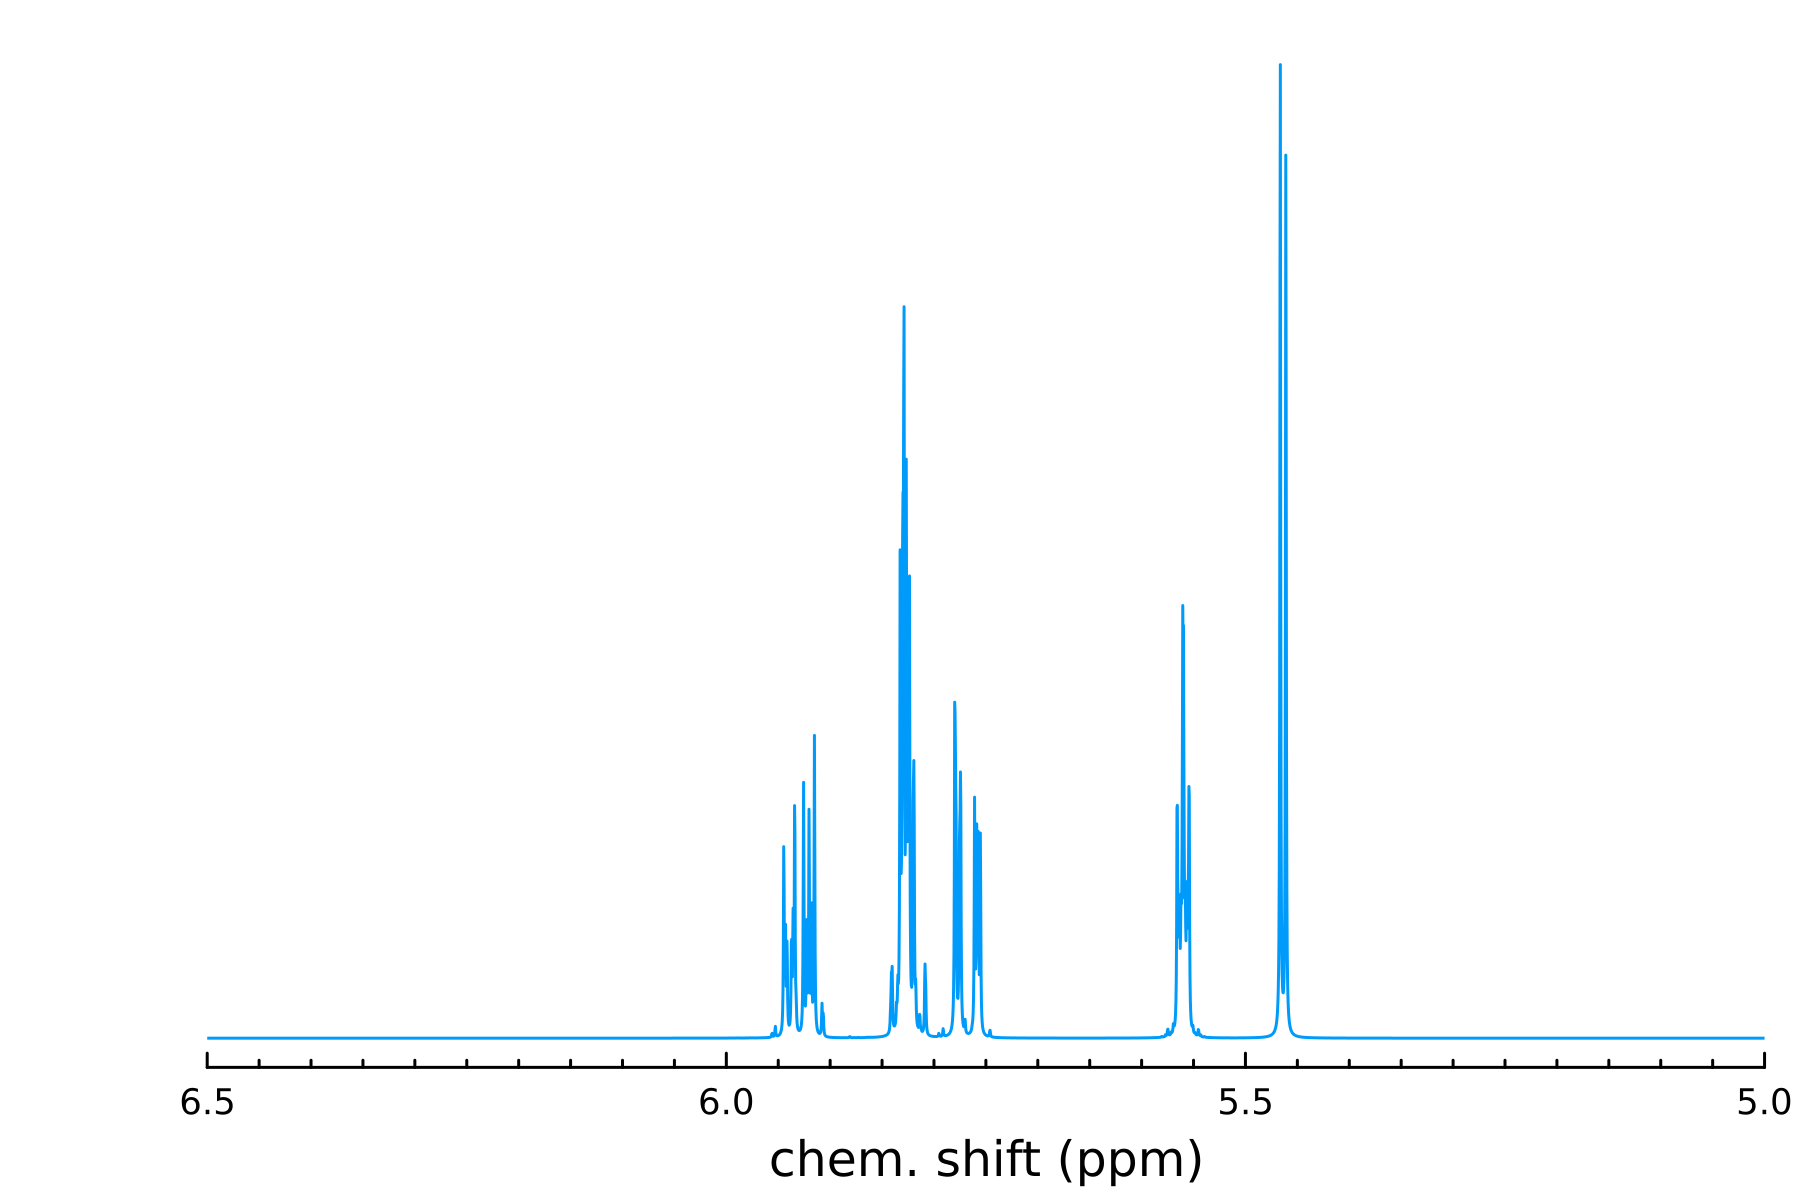

In [12]:
Plots.plot(range(-0.5/δt,stop=0.5/δt,length=length(fid))/600.0.+4.78, 
            real.(fftshift(fft(fidl))),
            xaxis=:flip,
            minorticks=10,
            xlabel="chem. shift (ppm)",
            xlims=[5,6.5],
            yaxis=false,
            grid=false,
            legend=false,
            fmt=:png,dpi=300,
)
#savefig("Gluconate-spect.png")

In [20]:
a=Plots.spy(abs.(Psup),title="nnz=$(nnz(Psup))",legend=false,fmt=:png,dpi=300);
savefig(a,"Psup-spy.png")

a=Plots.spy(abs.(Hsup),title="nnz=$(nnz(Hsup))",legend=false,fmt=:png,dpi=300);
savefig(a,"Hsup-spy.png")

"/home/mu3q/Source/NMRlab/src/Hsup-spy.png"

## Using `NMRlab` processing tools

In [15]:
d=NMRlab.SpectData(fidl,(range(0,step=δt, length=length(fidl)),))

32768-element SpectData{ComplexF64, 1} with coords:(0.0:0.00014609943812857477:4.787240289159009,):
                   96.0 + 0.0im
      82.82473915138137 + 47.72549043171315im
     47.314091913614455 + 81.70347228136802im
    0.09048465321023971 + 92.48704206985003im
     -44.96493498013946 + 77.77466841149737im
       -75.084696941851 + 42.95654040711833im
     -82.53373126021863 - 0.8008501407057966im
     -66.80777914935386 - 40.254992031737984im
     -34.44107711978784 - 64.31746233857325im
     3.4368119286353016 - 67.41402973043493im
                        ⋮
   0.007397862991945195 - 0.0052125877370617045im
   0.008967584998859432 - 0.00033796420458975714im
   0.007606449849383384 + 0.004553150195933373im
    0.00381848527874437 + 0.00784487098774779im
 -0.0010860681704011896 + 0.008486669306683167im
 -0.0054497556880489335 + 0.006341733120281001im
  -0.007839444530375527 + 0.0022156908886794744im
  -0.007530335142002489 - 0.0024397475484760046im
  -0.004735715310703319 - 0.00

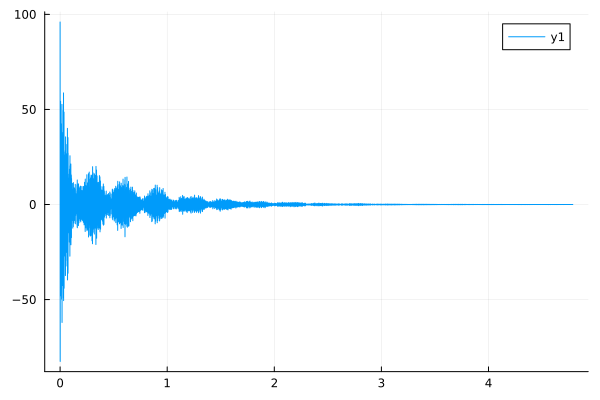

In [23]:
Plots.plot(NMRlab.coords(d,1),real(d))

In [31]:
process = Chain(
    ZeroFill([2^16]),
    Apodize([0.5π]),
    FourierTransform([2^16],[1])
)

FourierTransform(Integer[1], Integer[65536], true, FFTW forward plan for 65536-element array of ComplexF64
(dft-ct-dit/32
  (dftw-direct-32/8 "t3fv_32_avx2_128")
  (dft-vrank>=1-x32/1
    (dft-ct-dit/32
      (dftw-direct-32/8 "t3fv_32_avx2_128")
      (dft-direct-64-x32 "n2fv_64_avx2_128"))))) ∘ Apodize(Union{Colon, Real}[1.5707963267948966]) ∘ ZeroFill(Union{Colon, Integer}[65536])

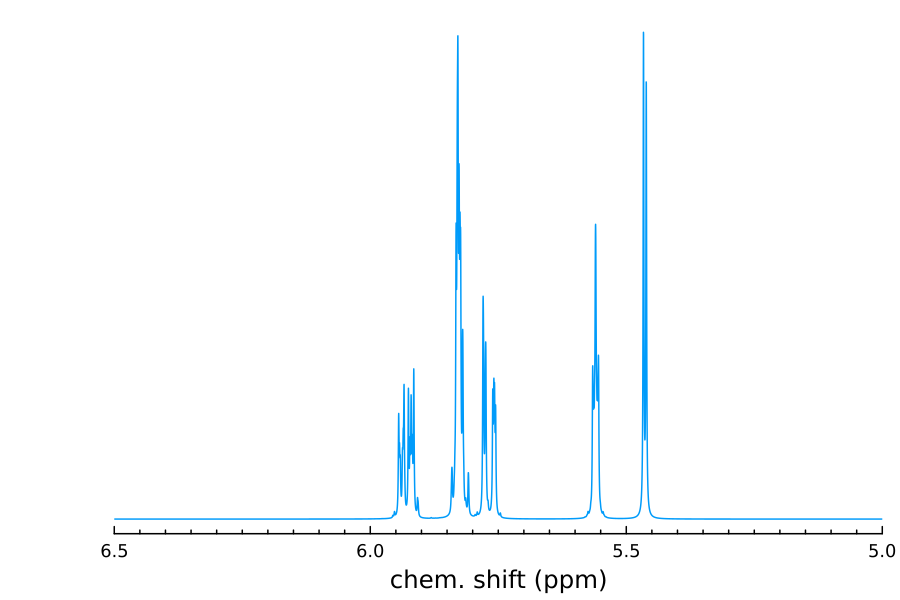

In [32]:
s=process(d)
Plots.plot(NMRlab.coords(s,1)./600.0.+4.78,
    real(s),
    xaxis=:flip,
    minorticks=10,
    xlabel="chem. shift (ppm)",
    xlims=[5,6.5],
    yaxis=false,
    grid=false,
    legend=false,
    fmt=:png,dpi=150,)